## **Project Title**

**Dataset:** This Jupyter Notebook focuses on both **Exploratory Data Analysis (EDA)** and **Machine Learning (ML)** using the Fetal Health Classification Dataset, which contains features extracted from Cardiotocogram (CTG) examinations. The notebook explores the dataset through statistical analysis and visualizations, followed by the development and evaluation of predictive models for fetal health classification.

**Objective:** The primary objective of this project is to gain a deeper understanding of the factors associated with fetal health outcomes (Normal, Suspect, and Pathological) and to develop machine learning models capable of accurately classifying fetal health status based on CTG measurements. The analysis seeks to uncover meaningful patterns within the data, identify the most influential predictors of fetal distress, and evaluate the effectiveness of various classification algorithms.

## **Table of content**

0. [Import Libraries](#0-import-libraries)
1. [Data Understanding](#1-data-understanding)
2. [Data Quality Assessment](#2-data-quality-assessment)
3. [Exploratory Data Analysis](#3-exploratory-data-analysis)
4. [Data Preprocessing](#4-data-preprocessing)
5. [Machine Learning Models](#5-machine-learning-modelling)
   - 5.1 [Baseline Models Trained with Original Data](#51-baseline-models-trained-with-original-data)
   - 5.2 [Models Trained with Data Oversampled with SMOTE](#52-models-trained-with-data-oversampled-with-smote)
   - 5.3 [Feature Importance Analysis](#53-feature-importance-analysis)
6. [Key Findings](#6-key-findings)
7. [Recommendations](#7-recommendations)

### **0. Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.metrics import accuracy_score,precision_score, recall_score, f1_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

# load dataset
df = pd.read_csv("data/fetalHealth.csv")

# Define the mycolor function

def mycolor(*color_names):
    colors = {
        "light_blue": "#2f4b7c",
        "smooth_blue": "#4B87CB",
        "light_purple": "#665191",
        "dark_pink": "#a05195",
        "light_pink": "#d45087",
        "light_red": "#f95d6a",
        "dark_orange": "#ff6347",
        "semi_orange": "#e79658",
        "orange": "#dda15a",
        "cream": "#b59378",
        "dark_cream": "#A57F5F",
        "choc": "#85664B",
        "dark_choc": "#6b5340",
        "light_orange": "#ff7c43",
        "light_cream": "#DAC0A7",
        "maroon_1": "#800021",
        "gold_1": "#cba135",
        "bright_maroon": "#C32148",
        "pink_2": "#B76E78",
        "pink_1": "#ffcccb",
        "maroon": "#5A0017"
    }

    if len(color_names) == 1:
       return colors[color_names[0]]

    return [colors[name] for name in color_names]


### **1. Data Understanding**

#### **1.1 Dataset Overview**
This dataset contains 2,126 cardiotocogram (CTG) records used to assess fetal health during pregnancy. Each record in the dataset represents features extracted from a CTG examination. The dataset consists of 21 predictor variables describing fetal heart rate characteristics, fetal movements, uterine activity, variability measures, and histogram-based statistical features. 

##### *Target variable is **fetal health**.*
* **Normal (1):** No signs of fetal distress.
* **Suspect (2):** Potential concerns requiring closer monitoring.
* **Pathological (3):** Significant abnormalities indicating possible fetal distress and the need for immediate medical attention.

##### *Predictor Variables*

* **baseline value** – Baseline fetal heart rate (beats per minute).
* **accelerations** – Number of accelerations per second.
* **fetal movement** – Number of fetal movements per second.
* **uterine contractions** – Number of uterine contractions per second.
* **light decelerations** – Number of light decelerations per second.
* **severe decelerations** – Number of severe decelerations per second.
* **prolongued decelerations** – Number of prolonged decelerations per second.
* **abnormal short term variability** – Percentage of time with abnormal short-term variability.
* **mean value of short term variability** – Average short-term variability.
* **percentage of time with abnormal long term variability** – Percentage of time with abnormal long-term variability.
* **mean value of long term variability** – Average long-term variability.
* **histogram width** – Width of the fetal heart rate histogram.
* **histogram min** – Minimum value of the histogram.
* **histogram max** – Maximum value of the histogram.
* **histogram number of peaks** – Number of peaks in the histogram.
* **histogram number of zeroes** – Number of zero values in the histogram.
* **histogram mode** – Most frequently occurring value.
* **histogram mean** – Mean value of the histogram.
* **histogram median** – Median value of the histogram.
* **histogram variance** – Variability of histogram values.
* **histogram tendency** – Overall trend or tendency of the histogram.


#### **1.2 Dataset Dimension**

In [2]:
df.shape

(2126, 22)

**Observation:**
The dataset consists of **2,126 cardiotocogram examinations** and **22 variables**. Of these variables, **21 are predictor features** describing fetal health characteristics, while **one variable (`fetal_health`) serves as the target variable** for classification.

#### **1.3 Data Types**

In [3]:
df.dtypes

baseline value                                            float64
accelerations                                             float64
fetal_movement                                            float64
uterine_contractions                                      float64
light_decelerations                                       float64
severe_decelerations                                      float64
prolongued_decelerations                                  float64
abnormal_short_term_variability                           float64
mean_value_of_short_term_variability                      float64
percentage_of_time_with_abnormal_long_term_variability    float64
mean_value_of_long_term_variability                       float64
histogram_width                                           float64
histogram_min                                             float64
histogram_max                                             float64
histogram_number_of_peaks                                 float64
histogram_

**Observation:**
All variables are numerical and stored as floating-point values. No categorical variables are present.

#### **1.4 Statistical Summary**

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
baseline value,2126.0,133.303857,9.840844,106.0,126.000,133.000,140.000,160.000
accelerations,2126.0,0.003178,0.003866,0.0,0.000,0.002,0.006,0.019
fetal_movement,2126.0,0.009481,0.046666,0.0,0.000,0.000,0.003,0.481
uterine_contractions,2126.0,0.004366,0.002946,0.0,0.002,0.004,0.007,0.015
light_decelerations,2126.0,0.001889,0.002960,0.0,0.000,0.000,0.003,0.015
severe_decelerations,2126.0,0.000003,0.000057,0.0,0.000,0.000,0.000,0.001
prolongued_decelerations,2126.0,0.000159,0.000590,0.0,0.000,0.000,0.000,0.005
abnormal_short_term_variability,2126.0,46.990122,17.192814,12.0,32.000,49.000,61.000,87.000
mean_value_of_short_term_variability,2126.0,1.332785,0.883241,0.2,0.700,1.200,1.700,7.000
percentage_of_time_with_abnormal_long_term_variability,2126.0,9.846660,18.396880,0.0,0.000,0.000,11.000,91.000


**Key Observations:**

* The baseline fetal heart rate averages approximately 133 bpm, with values ranging from 106 to 160 bpm.
* Acceleration, fetal movement, and deceleration variables have median values close to zero, indicating these events occur infrequently in many examinations.
* Variability measures show considerable spread, suggesting differences in fetal heart rate patterns across observations.
* Histogram-based features exhibit wide ranges, indicating substantial variation in fetal heart rate distributions.
* Several variables have large gaps between their median and maximum values, suggesting the presence of potential outliers.
* Predictor variables are measured on different scales.
* The target variable consists of three classes representing Normal, Suspect, and Pathological fetal health outcomes.

#### **1.5 Sample Observations**

In [5]:
df.head()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


**Observations:**
Each row represents a single CTG examination, while each column represents a physiological measurement or derived statistic associated with fetal health.

#### **1.6 Features Categories**
The predictor variables were grouped into clinically meaningful categories based on their physiological interpretation and measurement characteristics. Variables describing fetal heart rate patterns, fetal movements, and uterine contractions were classified as `Fetal Heart Rate and Uterine Activity Features`. Measures quantifying short-term and long-term heart rate fluctuations were classified as `Variability Features`. Statistical measures derived from fetal heart rate histograms were classified as `Histogram-Based Features`. This grouping follows the underlying clinical concepts used in cardiotocography for fetal assessment.


In [6]:
target_feature = ['fetal_health']

heart_rate_uterine_activity_features = [
'baseline value',
'accelerations',
'fetal_movement',
'uterine_contractions',
'light_decelerations',
'severe_decelerations',
'prolongued_decelerations']

variability_features = [
'abnormal_short_term_variability',
'mean_value_of_short_term_variability',
'percentage_of_time_with_abnormal_long_term_variability',
'mean_value_of_long_term_variability']

histogram_features = [
'histogram_width',
'histogram_min',
'histogram_max',
'histogram_number_of_peaks',
'histogram_number_of_zeroes',
'histogram_mode',
'histogram_mean',
'histogram_median',
'histogram_variance',
'histogram_tendency']

predictor_features = (heart_rate_uterine_activity_features +
                      variability_features +
                      histogram_features)

df.columns


Index(['baseline value', 'accelerations', 'fetal_movement',
       'uterine_contractions', 'light_decelerations', 'severe_decelerations',
       'prolongued_decelerations', 'abnormal_short_term_variability',
       'mean_value_of_short_term_variability',
       'percentage_of_time_with_abnormal_long_term_variability',
       'mean_value_of_long_term_variability', 'histogram_width',
       'histogram_min', 'histogram_max', 'histogram_number_of_peaks',
       'histogram_number_of_zeroes', 'histogram_mode', 'histogram_mean',
       'histogram_median', 'histogram_variance', 'histogram_tendency',
       'fetal_health'],
      dtype='object')

### **2. Data Quality Assessment**

#### 2.1 Missing Values

In [7]:
df.isnull().sum()

baseline value                                            0
accelerations                                             0
fetal_movement                                            0
uterine_contractions                                      0
light_decelerations                                       0
severe_decelerations                                      0
prolongued_decelerations                                  0
abnormal_short_term_variability                           0
mean_value_of_short_term_variability                      0
percentage_of_time_with_abnormal_long_term_variability    0
mean_value_of_long_term_variability                       0
histogram_width                                           0
histogram_min                                             0
histogram_max                                             0
histogram_number_of_peaks                                 0
histogram_number_of_zeroes                                0
histogram_mode                          

The dataset has no missing values.

#### 2.2 Duplicated Records

In [8]:
# duplicated rows together with original row 
df[df.duplicated(keep = False)]


,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
67,140.0,0.007,0.000,0.004,0.0,0.0,0.0,34.0,1.2,0.0,...,119.0,179.0,2.0,0.0,156.0,153.0,155.0,5.0,0.0,1.0
68,140.0,0.007,0.000,0.004,0.0,0.0,0.0,34.0,1.2,0.0,...,119.0,179.0,2.0,0.0,156.0,153.0,155.0,5.0,0.0,1.0
229,123.0,0.003,0.003,0.000,0.0,0.0,0.0,52.0,0.8,2.0,...,50.0,140.0,7.0,0.0,129.0,128.0,130.0,4.0,1.0,1.0
233,123.0,0.000,0.000,0.000,0.0,0.0,0.0,49.0,0.8,7.0,...,63.0,137.0,2.0,0.0,129.0,127.0,129.0,2.0,1.0,1.0
234,123.0,0.000,0.000,0.000,0.0,0.0,0.0,49.0,0.8,7.0,...,63.0,137.0,2.0,0.0,129.0,127.0,129.0,2.0,1.0,1.0
304,145.0,0.000,0.020,0.000,0.0,0.0,0.0,77.0,0.2,45.0,...,129.0,150.0,1.0,0.0,146.0,145.0,147.0,0.0,1.0,2.0
306,145.0,0.000,0.020,0.000,0.0,0.0,0.0,77.0,0.2,45.0,...,129.0,150.0,1.0,0.0,146.0,145.0,147.0,0.0,1.0,2.0
323,135.0,0.000,0.000,0.000,0.0,0.0,0.0,62.0,0.5,71.0,...,71.0,168.0,3.0,0.0,143.0,142.0,144.0,1.0,1.0,3.0
324,135.0,0.000,0.000,0.000,0.0,0.0,0.0,62.0,0.5,71.0,...,71.0,168.0,3.0,0.0,143.0,142.0,144.0,1.0,1.0,3.0
326,144.0,0.000,0.019,0.000,0.0,0.0,0.0,76.0,0.4,61.0,...,71.0,152.0,3.0,0.0,145.0,144.0,146.0,2.0,1.0,2.0


**Observation:**

The dataset contains 13 duplicated records as identified using `df.duplicated()`, which compares all columns in the dataset.

**Action:**

These records will be removed because they contain identical values across all variables and therefore do not provide additional information for the analysis.

In [9]:
# drop duplicated rows
df = df.drop(df[df.duplicated()].index)


### **3. Exploratory Data Analysis**
#### **3.1 Target Variable Distribution**

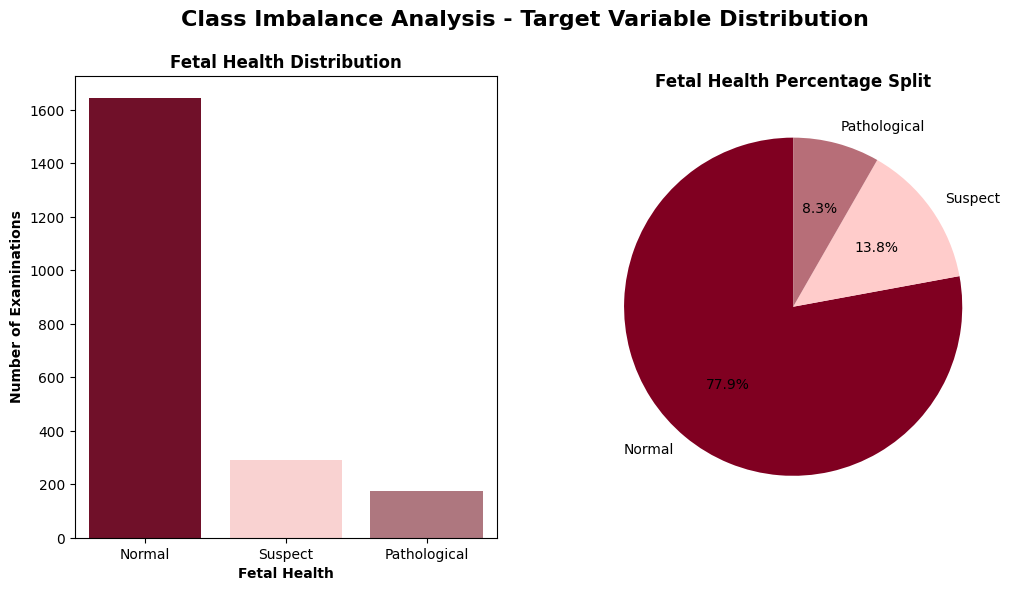

In [10]:
# target variable distribution
target_distribution = df['fetal_health'].value_counts().sort_index().reset_index()

# add percentage of distribution
target_distribution['percentage'] = (target_distribution['count']/len(df)*100).round(2)

# plot the distribution
fig, (ax1, ax2) = plt.subplots(1,2, figsize =(12,6))

# set main title
fig.suptitle('Class Imbalance Analysis - Target Variable Distribution', fontsize = 16, fontweight = 'bold', y =0.99)

# plot barplot
sns.barplot(
    data = target_distribution,
    x = 'fetal_health',
    y = 'count',
    hue = 'fetal_health',
    palette = mycolor('maroon_1', 'pink_1', 'pink_2'),
    ax =ax1,
    legend = False
)

ax1.set_title('Fetal Health Distribution', fontweight ='bold')
ax1.set_xlabel('Fetal Health', fontweight ='bold')
ax1.set_ylabel('Number of Examinations', fontweight = 'bold')
ax1.set_xticks([0, 1, 2])  # The index positions of your plotted bars
ax1.set_xticklabels(['Normal', 'Suspect', 'Pathological']) 


# plot pie chart percentage

ax2.pie(
    target_distribution['count'], 
    colors = mycolor('maroon_1', 'pink_1', 'pink_2'), 
    labels =['Normal', 'Suspect', 'Pathological'],
    autopct='%1.1f%%',
    startangle=90,)
ax2.set_title('Fetal Health Percentage Split', fontweight ='bold')

plt.savefig("images/target_variable_distribution.png", dpi = 300, bbox_inches='tight')



**Key Observation:**

The target variable has a noticeable class imbalance. The **Normal** class accounts for approximately **77.9%** of all observations, while the **Suspect** and **Pathological** classes represent only **13.8%** and **8.3%**, respectively.

This imbalance may cause machine learning models to become biased toward the majority class, resulting in poor predictive performance for the minority classes.  Class balancing techniques, such as class weighting or resampling methods, will be explored further during model development.

#### **3.2 Univariate Analysis**

##### ***3.2.1 Fetal Heart Rate and Uterine Activity Features***

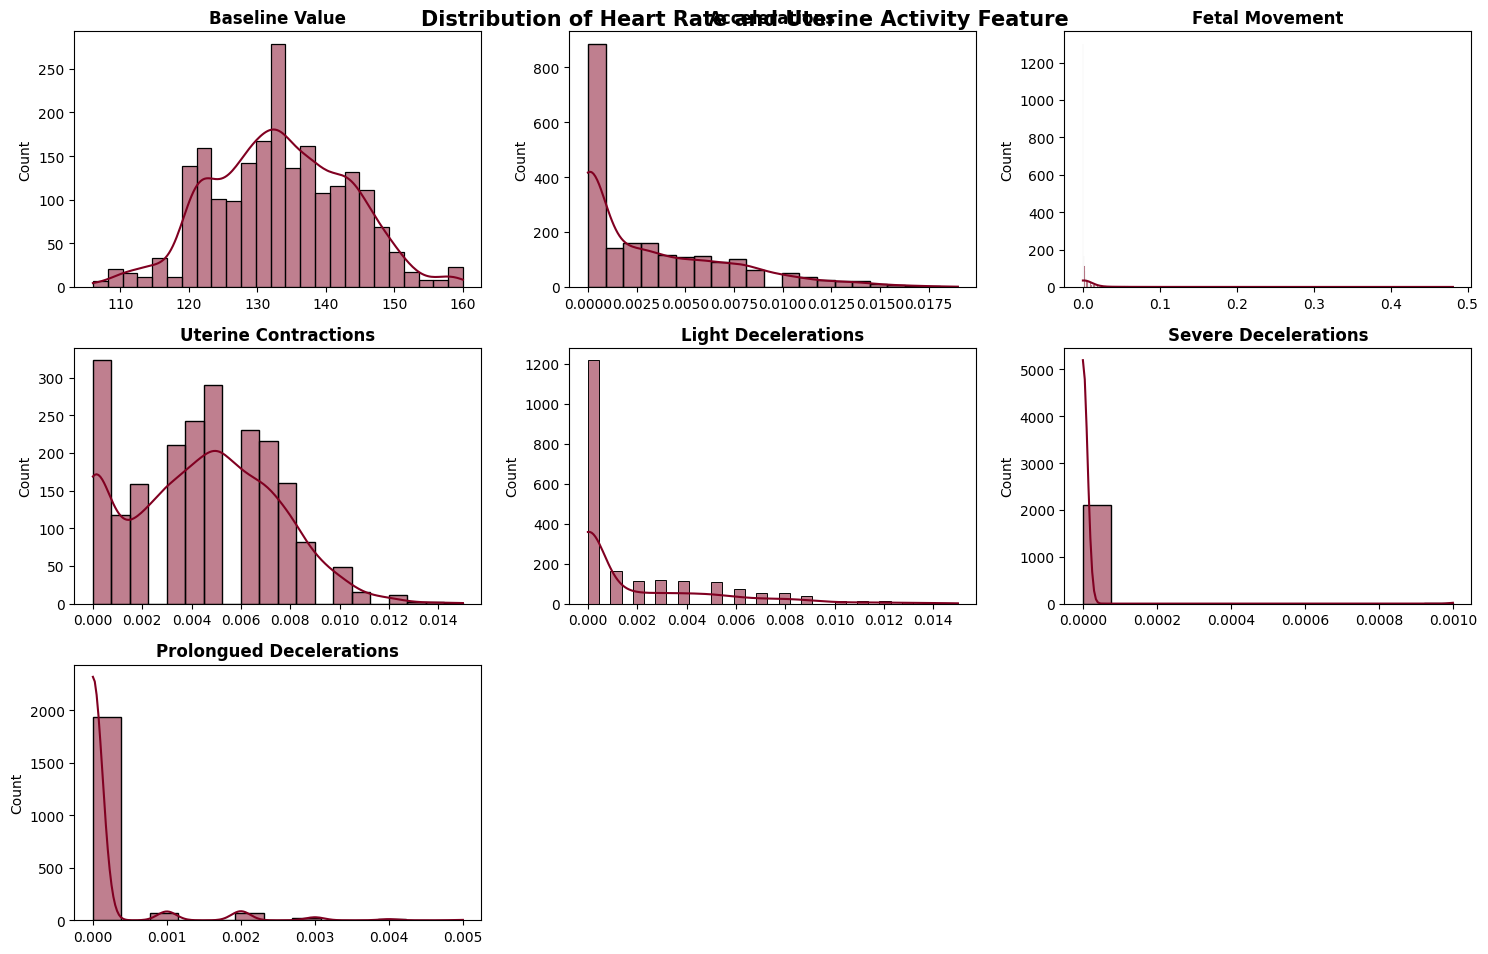

In [11]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
fig.suptitle('Distribution of Heart Rate and Uterine Activity Feature', fontsize = 15, fontweight = 'bold', y =0.95)

for ax, feature in zip(axes.flatten(), heart_rate_uterine_activity_features):
    sns.histplot(
        data=df,
        x=feature,
        kde=True,
        color=mycolor('maroon_1'),
        ax=ax
    )
    ax.set_title(feature.replace('_', ' ').title(), fontweight='bold')
    ax.set_xlabel("")

for ax in axes.flatten()[len(heart_rate_uterine_activity_features):]:
    fig.delaxes(ax)

plt.savefig("images/heart_rate_uterine_activity.png", dpi = 300, bbox_inches='tight')
plt.tight_layout()

**Key Observations**

* `Baseline fetal heart rate` values are concentrated between 120 and 150 bpm, with a peak around 130–140 bpm.
* `Accelerations` and all `deceleration` variables are highly right-skewed, with most observations close to zero.
* `Fetal movement` contains many zero values, indicating that measurable fetal movements are not recorded in many examinations.
* `Uterine contractions` occur more frequently than `fetal movements` and `decelerations` but are still concentrated at lower values.
* `Severe` and `prolonged decelerations` are rare events in the dataset, suggesting that these events may be associated with abnormal fetal conditions and could be important predictive features.

##### ***3.2.2 Variability Features***

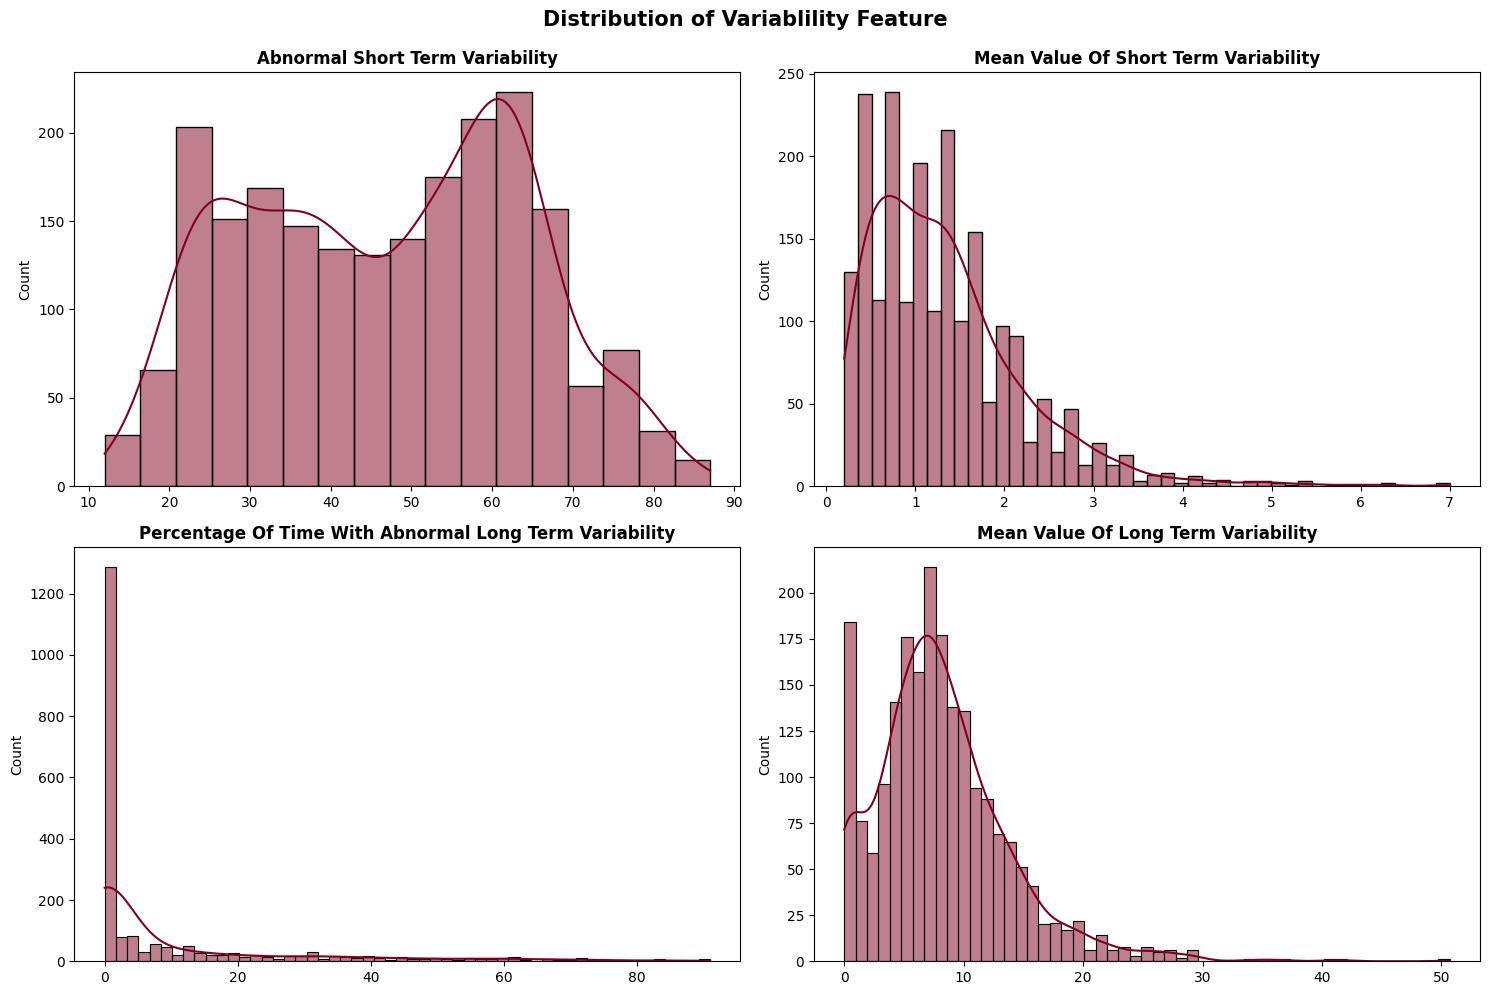

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Distribution of Variablility Feature', fontsize = 15, fontweight = 'bold', y =0.99)

for ax, feature in zip(axes.flatten(), variability_features):
    sns.histplot(
        data=df,
        x=feature,
        kde=True,
        color=mycolor('maroon_1'),
        ax=ax
    )

    ax.set_title(feature.replace('_', ' ').title(), fontweight='bold')
    ax.set_xlabel("")
  
    plt.savefig("images/variability_features.png", dpi = 300, bbox_inches='tight')
    plt.tight_layout()
    

**Key Observations**

* `abnormal_short_term_variability` exhibits a bimodal distribution, with peaks around 20–30% and 55–65%.
* `mean_value_of_short_term_variability` is positively skewed, with most observations concentrated below 2.
* `percentage_of_time_with_abnormal_long_term_variability` contains a large number of zero values, indicating that abnormal long-term variability is absent in many examinations.
* `mean_value_of_long_term_variability` is moderately right-skewed, with most observations between 5 and 10, while a small number of examinations exhibit substantially higher values.


##### ***3.2.3 Histogram-Based Features***

<Figure size 2000x1500 with 0 Axes>

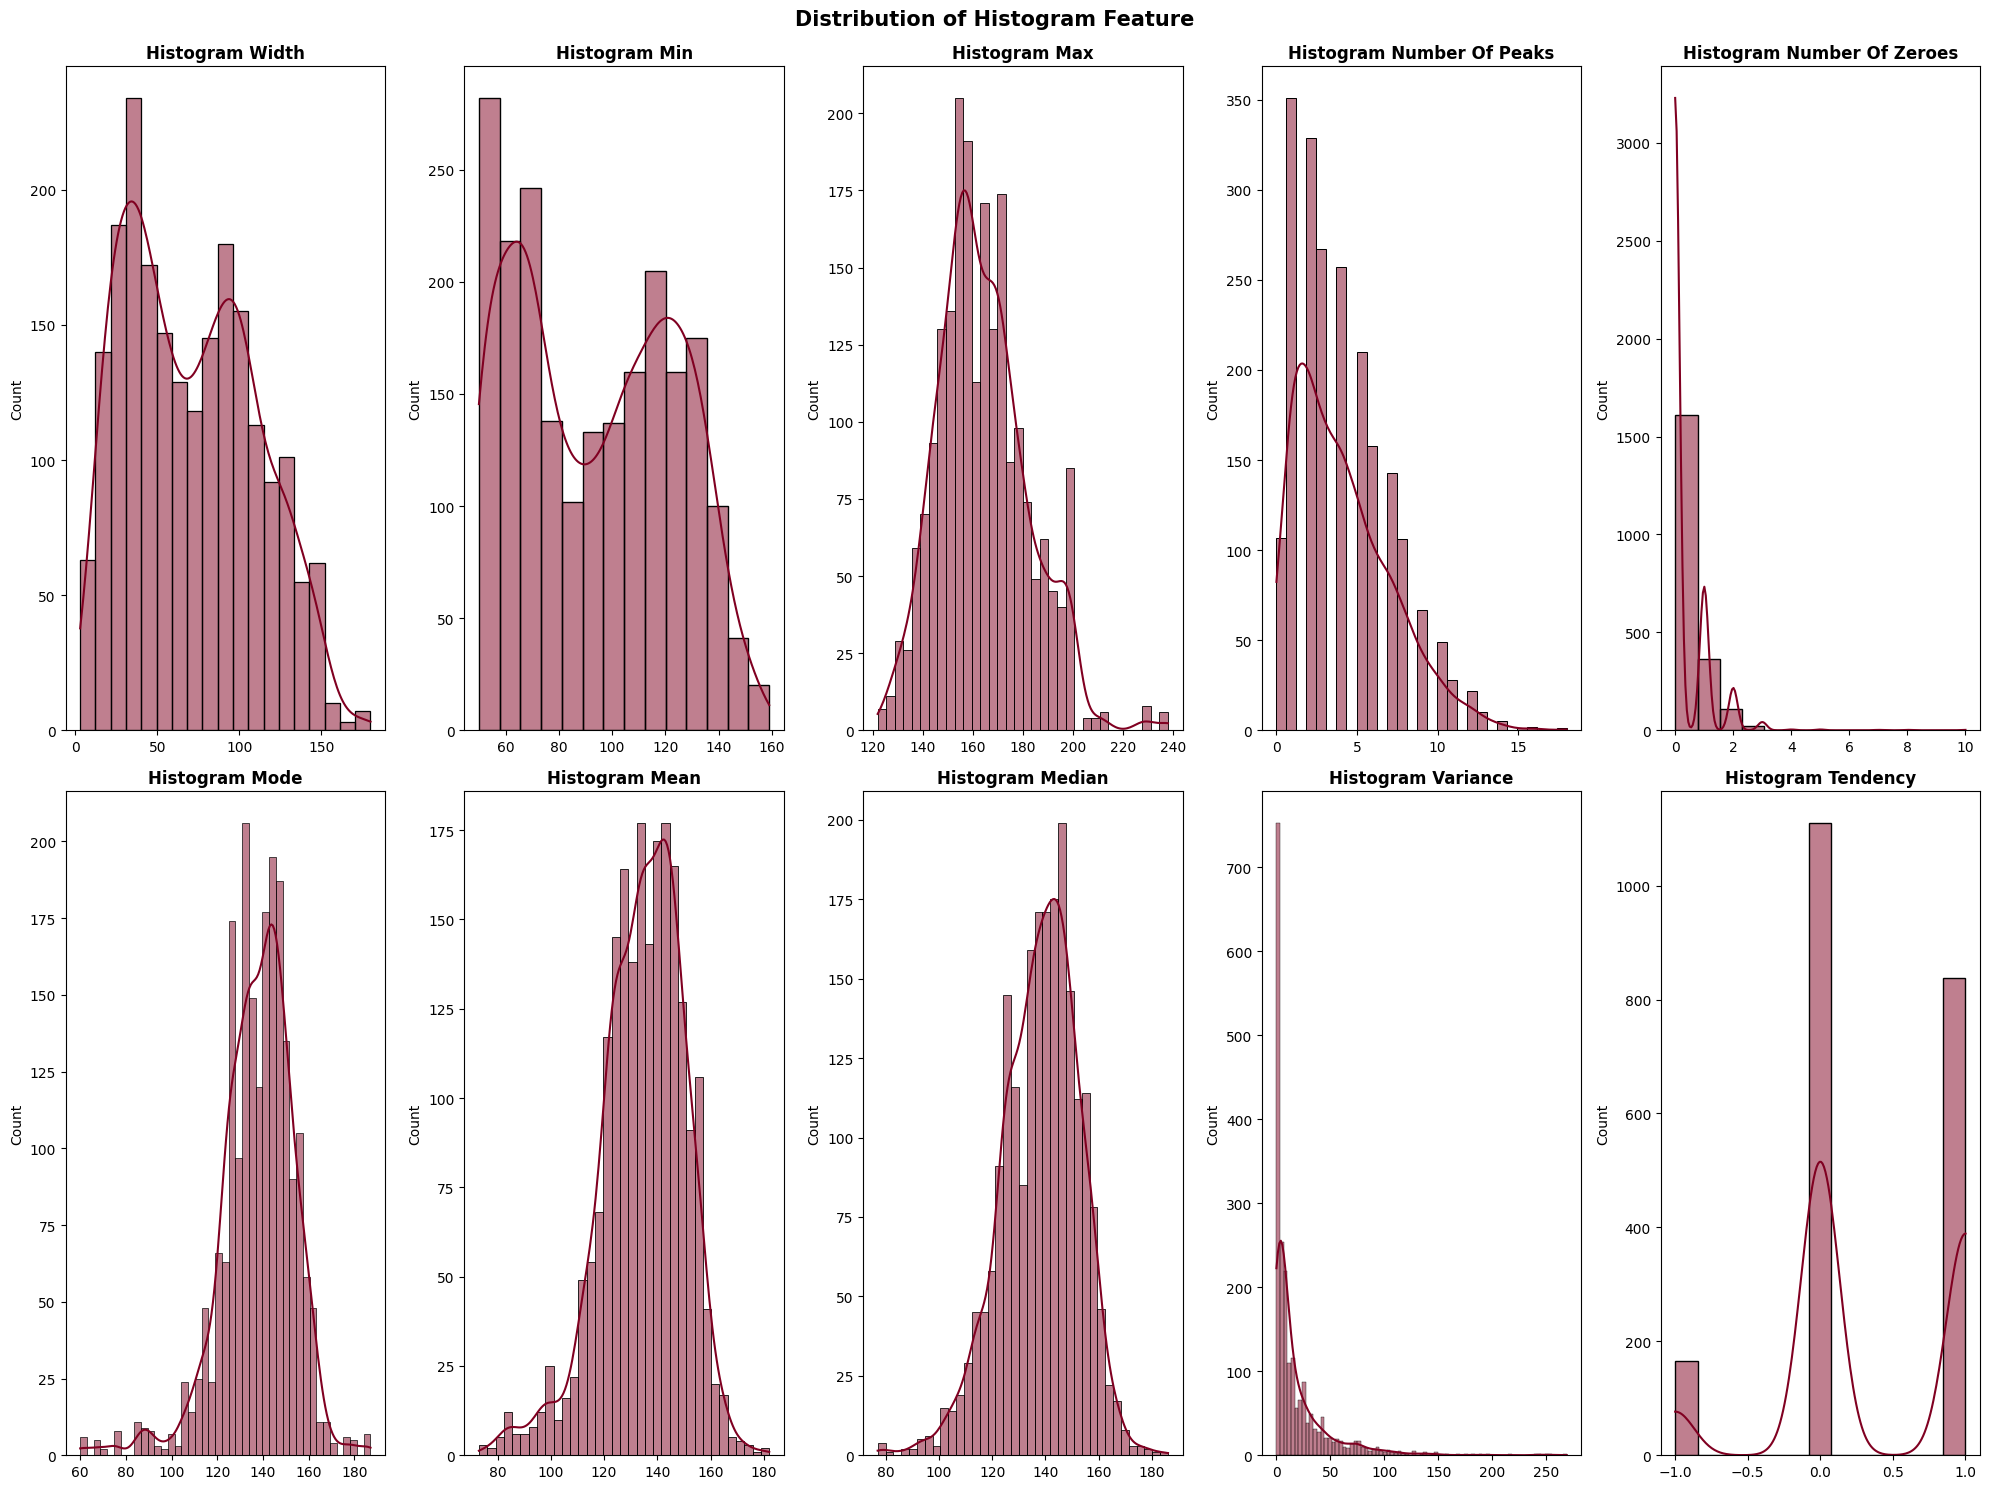

<Figure size 2000x1500 with 0 Axes>

In [13]:
fig, axes = plt.subplots(2,5, figsize =(20,15))
fig.suptitle('Distribution of Histogram Feature', fontsize = 15, fontweight = 'bold', y =0.99)

for ax, feature in zip(axes.flatten(), histogram_features):
    sns.histplot(
        data = df,
        x = feature,
        kde = True,
        color = mycolor('maroon_1'),
        ax = ax
    )
    ax.set_title(feature.replace('_', ' ').title(), fontweight='bold')
    ax.set_xlabel("")
    plt.savefig("images/histogram_features.png", dpi =300, bbox_inches = 'tight')
    plt.tight_layout()


plt.figure(figsize =(20,15))


**Key Observations**

* `histogram_width` and `histogram_min` have a bimodal distribution, suggesting the presence of multiple underlying patterns in the fetal heart rate recordings.
* `histogram_max` is approximately bell-shaped, with most observations concentrated between 140 and 180.
* `histogram_number_of_peaks` is positively skewed, with lower numbers of peaks occurring more frequently than higher numbers.
* `histogram_number_of_zeroes` contains a large number of zero values, indicating that many examinations have no histogram zeroes.
* `histogram_mode`, `histogram_mean`, and `histogram_median` are approximately normally distributed and centred around 130–150 bpm.
* `histogram_variance` is highly right-skewed, with most observations having low variance and a small number exhibiting substantially larger values.
* `histogram_tendency` is a discrete variable taking values of -1, 0, and 1, with most observations concentrated at 0 and 1.

#### **3.3 Bivariate Analysis (by Fetal Health)**

##### ***3.3.1 Fetal Heart Rate and Uterine Activity Features by Fetal Health***

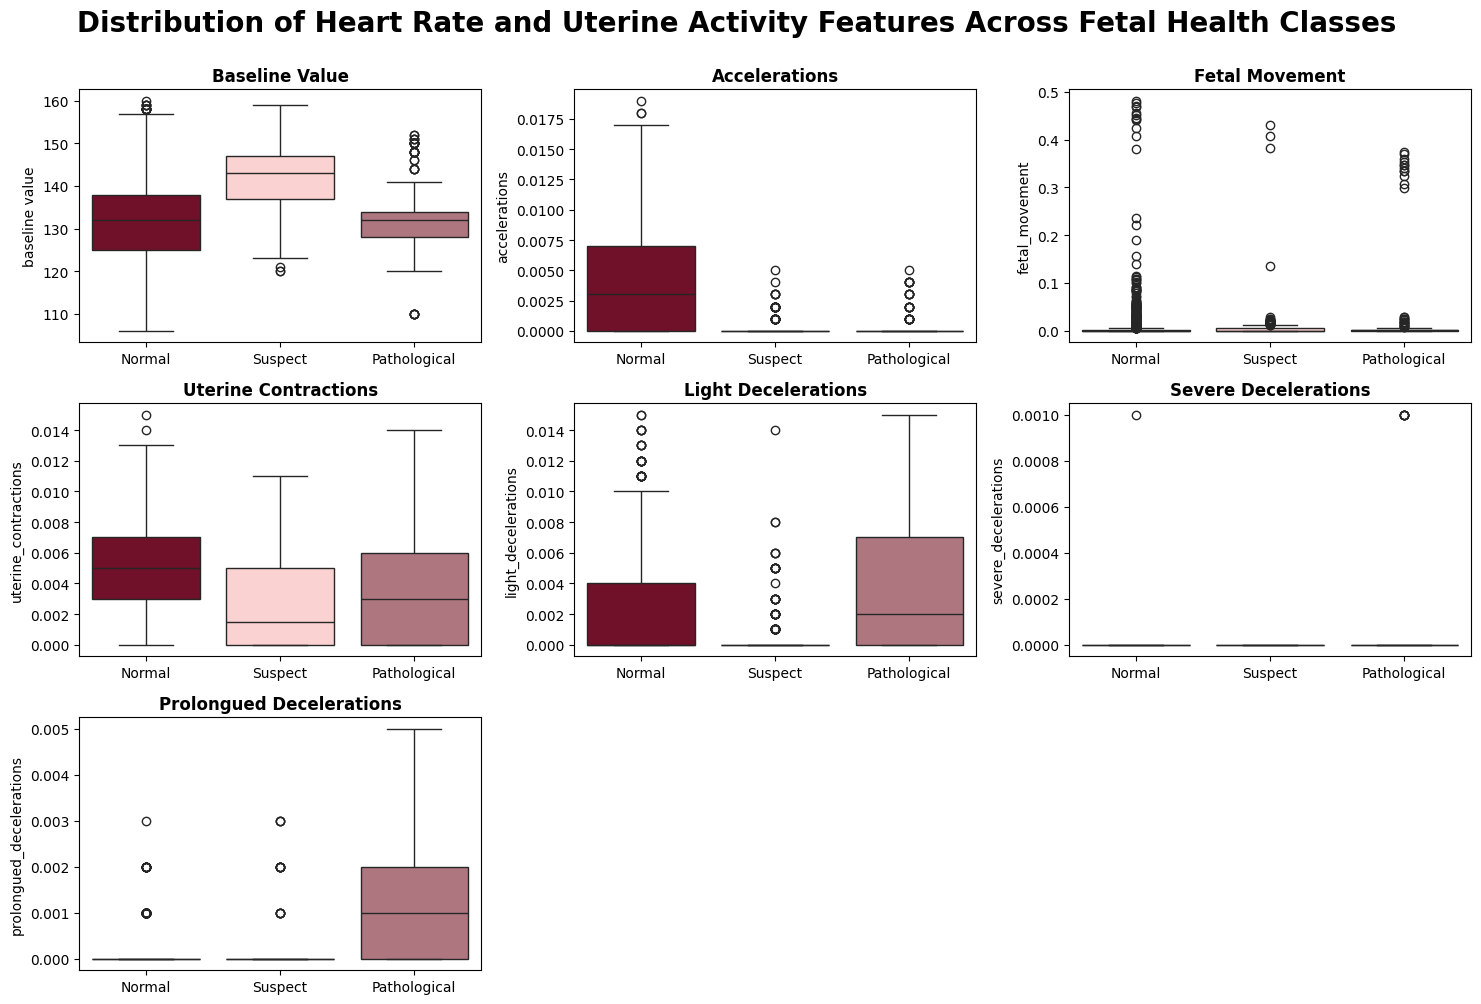

In [14]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
fig.suptitle('Distribution of Heart Rate and Uterine Activity Features Across Fetal Health Classes', fontsize=20, fontweight='bold',
y = 1)
for ax, feature in zip(axes.flatten(), heart_rate_uterine_activity_features):

    sns.boxplot(
        data=df,
        x='fetal_health',
        y=feature,
        palette=mycolor('maroon_1', 'pink_1', 'pink_2'),
        hue = 'fetal_health',
        ax = ax,
        legend = False
    )

    ax.set_title(feature.replace('_', ' ').title(), fontweight='bold')
    ax.set_xlabel("")
    ax.set_xticks([0, 1, 2])  # The index positions of your plotted bars
    ax.set_xticklabels(['Normal', 'Suspect', 'Pathological']) 


# delete the sublots with no featues
for ax in axes.flatten()[len(heart_rate_uterine_activity_features):]:
    fig.delaxes(ax)

plt.savefig("images/fetal_health_by_heart_rate_uterine_activity_features.png", dpi =300, bbox_inches = 'tight')
plt.tight_layout()

**Key Observations**

* For `baseline_value`, the Suspect class generally shows higher baseline heart rates than the Normal and Pathological classes.
* `Accelerations` are more common in the Normal class, while Suspect and Pathological cases contain predominantly low or zero acceleration values.
* `Fetal movement` shows little separation between classes, with most observations concentrated near zero across all groups.
* `Uterine contractions` tend to be higher in the Normal class and lower in the Suspect class.
* `Light decelerations` occur more frequently in the Pathological class than in the Normal and Suspect classes.
* `Severe decelerations` are extremely rare across all fetal health classes.
* `Prolonged decelerations` are more prevalent in the Pathological class.

##### ***3.3.2 Variability Features by Fetal Health***

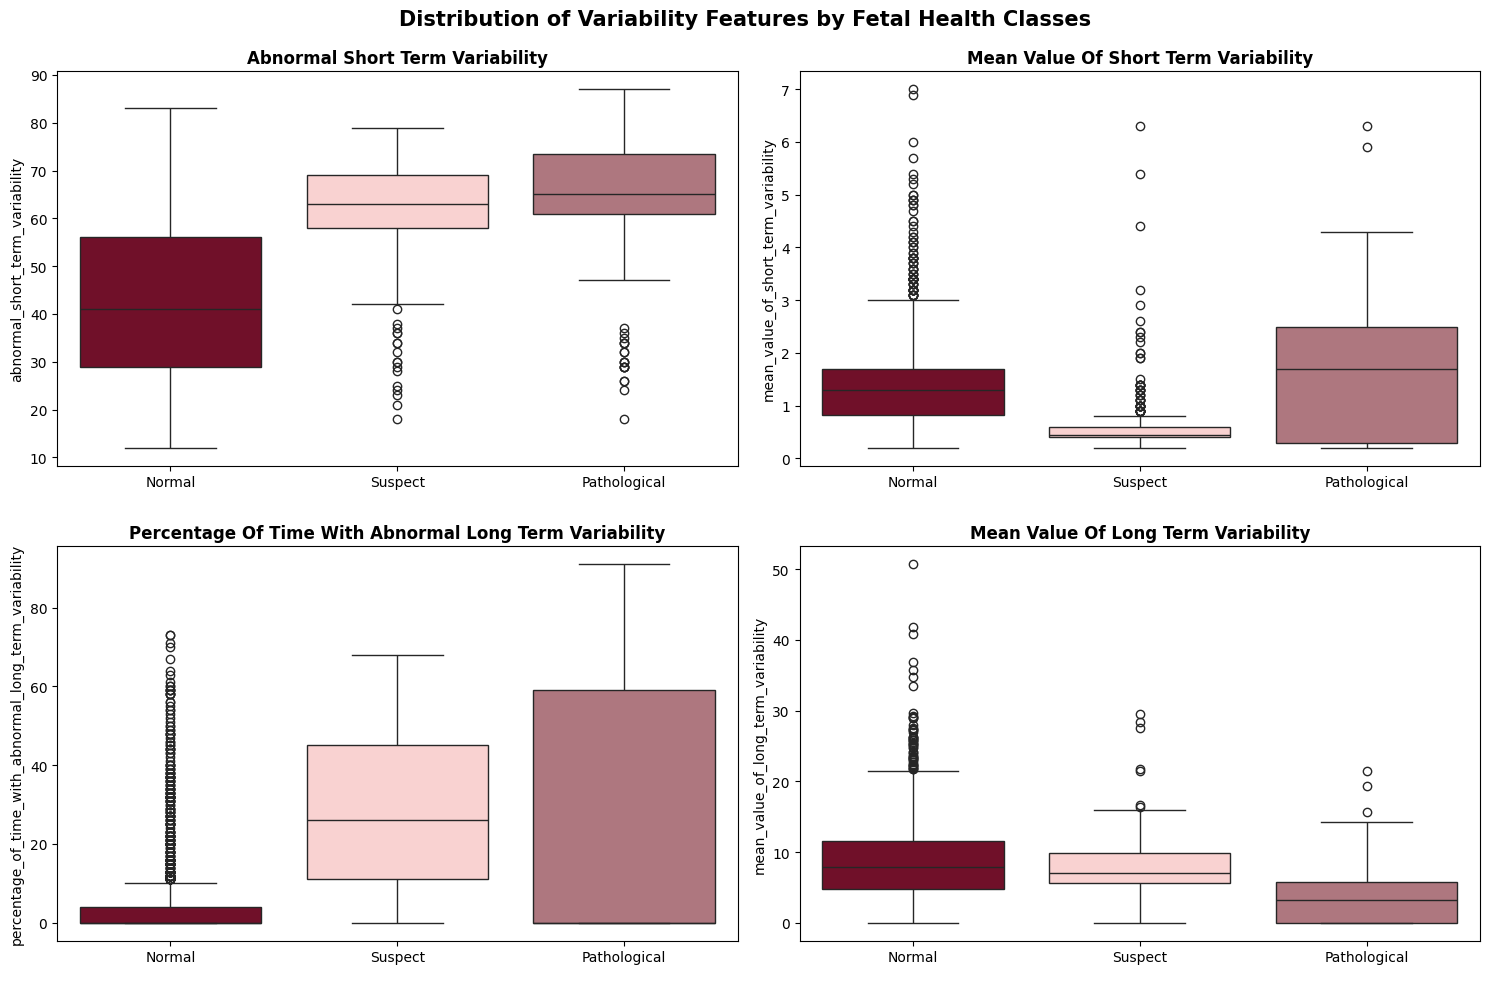

In [15]:
fig, axes = plt.subplots(2,2, figsize = (15,10))
fig.suptitle('Distribution of Variability Features by Fetal Health Classes', fontsize = 15, fontweight = 'bold', y = 0.99)

for ax, feature in zip(axes.flatten(), variability_features):
    sns.boxplot(
        data = df,
        x = 'fetal_health',
        y = feature,
        palette = mycolor('maroon_1', 'pink_1', 'pink_2'),
        hue = 'fetal_health',
        ax = ax,
        legend = False

    )
    ax.set_title(feature.replace('_', " ").title(), fontweight = 'bold')
    ax.set_xlabel(" ")
    ax.set_xticks([0, 1, 2])  # The index positions of your plotted bars
    ax.set_xticklabels(['Normal', 'Suspect', 'Pathological']) 
    

plt.savefig("images/fetal_health_by_variability_features.png", dpi =300, bbox_inches = 'tight')
plt.tight_layout()

**Key Observations**

* `abnormal_short_term_variability` increases from the Normal class (median = 41) to the Suspect (63) and Pathological (65) classes, indicating a relationship between abnormal short-term variability and poorer fetal health.
* `mean_value_of_short_term_variability` is lowest and most compressed in the Suspect class (median = 0.5), while Pathological shows a higher median (1.7) than Normal (1.3), though Normal has many more high-value outliers.
* `percentage_of_time_with_abnormal_long_term_variability` shows clear separation between classes, with Normal cases concentrated near zero and higher values observed in the Suspect and Pathological classes.
* `mean_value_of_long_term_variability` is similar between Normal and Suspect (medians = 7), while Pathological drops to a lower median (3).


##### ***3.3.3 Histogram Features by Fetal Health***

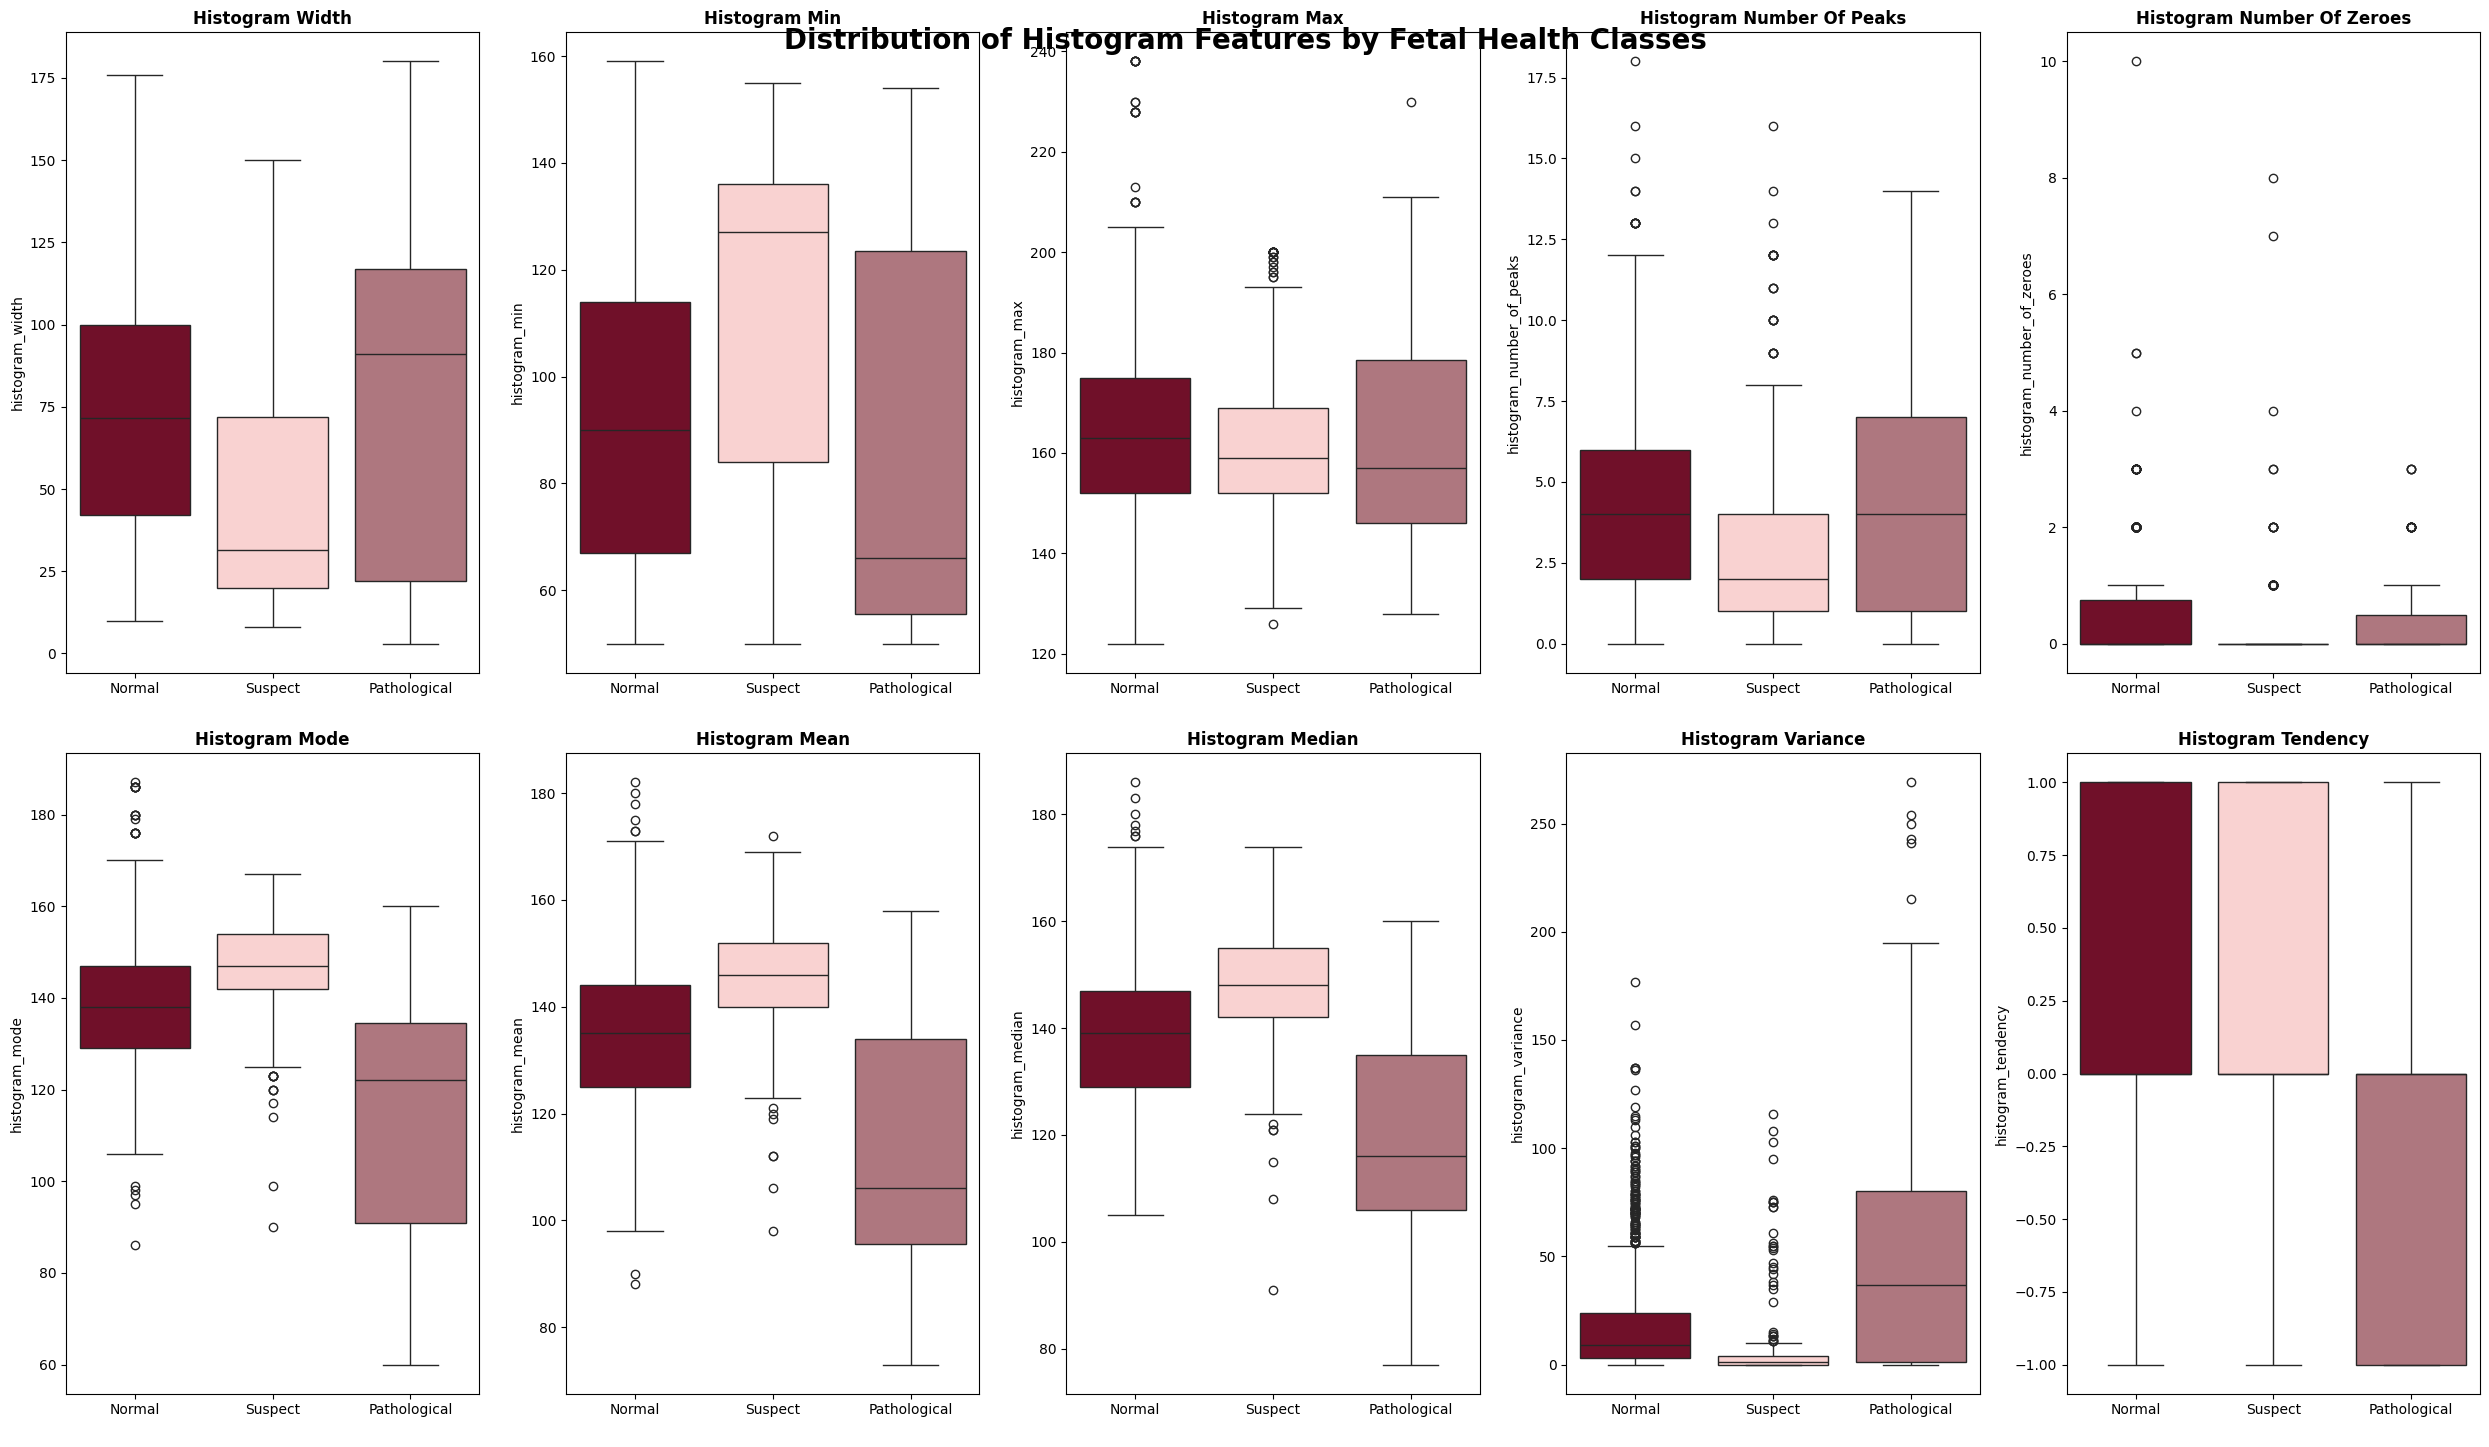

In [16]:
fig, axes = plt.subplots(2,5, figsize = (25,15))
fig.suptitle('Distribution of Histogram Features by Fetal Health Classes', fontsize = 20, fontweight = 'bold', y = 0.95)

for ax, feature in zip(axes.flatten(), histogram_features):
    sns.boxplot(
        data = df,
        x = 'fetal_health',
        y = feature,
        palette = mycolor('maroon_1', 'pink_1', 'pink_2'),
        hue = 'fetal_health',
        ax = ax,
        legend = False

    )
    ax.set_title(feature.replace('_', " ").title(), fontweight = 'bold')
    ax.set_xlabel(" ")
    ax.set_xticks([0, 1, 2])  # The index positions of your plotted bars
    ax.set_xticklabels(['Normal', 'Suspect', 'Pathological']) 

plt.savefig("images/fetal_health_by_histogram_features.png", dpi =300, bbox_inches = 'tight')
plt.tight_layout()

**Key Observations**

* For `histogram_width`, Pathological cases have the most spread-out histograms with the largest IQR (median ~91). Suspect is narrowest (median ~31), with Normal in between (median ~72).
* `histogram_min` is highest for Suspect (median ~127) and lowest for Pathological (median ~65), with Normal intermediate (~90).
* `histogram_max` is similar across all three classes (medians ~155–163).
* `histogram_number_of_peaks` is lowest in Suspect (median ~2) and similar between Normal and Pathological (median ~4), with Normal showing the most high outliers.
* `histogram_number_of_zeroes` is concentrated at zero for all classes, although the Suspect class contains the highest proportion of zero values.
* `histogram_mode`, `histogram_mean`, and `histogram_median` are noticeably lower in the Pathological class, indicating lower central fetal heart rate values compared with the Normal and Suspect classes.
* `histogram_variance` is substantially higher in the Pathological class.
* `histogram_tendency` differs across classes, with Normal and Suspect cases more frequently exhibiting positive tendencies, while Pathological cases are more concentrated at negative tendencies.

#### **3.4 Multivariate Analysis**

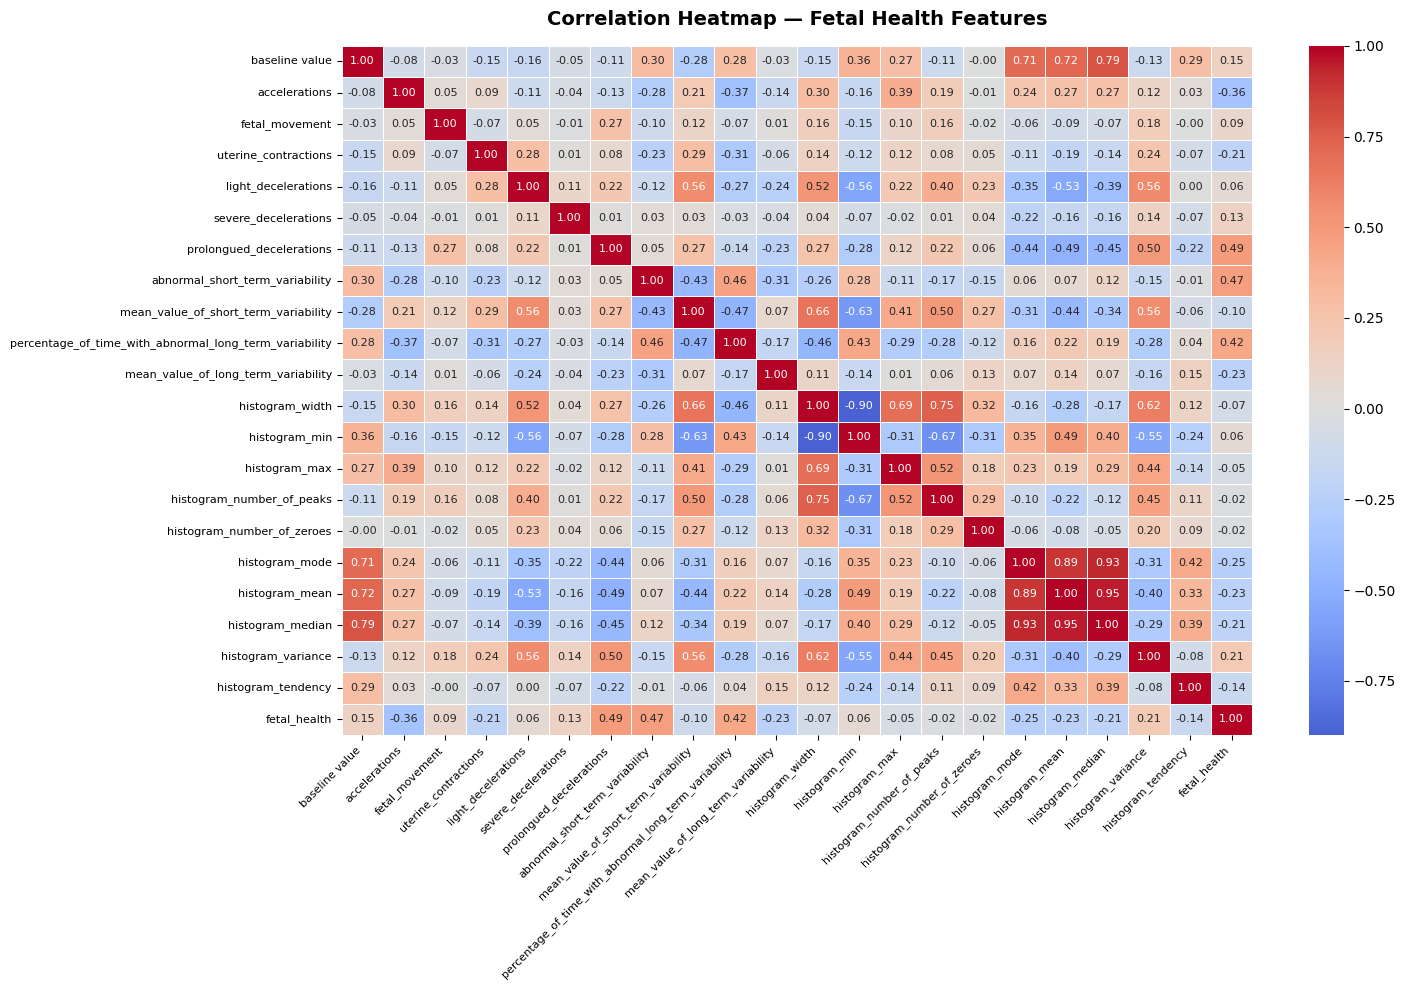

In [17]:
# plot canva
fig, ax = plt.subplots(1,1, figsize = (15,10))

sns.heatmap(
    df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    annot_kws={"size": 8}
)

plt.title("Correlation Heatmap — Fetal Health Features", fontsize=14, pad=15, fontweight = 'bold')
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig("images/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()



**Key Observations:**

To interpret the correlation matrix, the following table was used:

| r Value Range | Description |
|---|---|
| 0.7 to 1.0 | Strong positive |
| 0.4 to 0.69 | Moderate positive |
| 0.11 to 0.39 | Weak positive |
| -0.10 to 0.10 | Little to no linear relationship |
| -0.39 to -0.11 | Weak negative |
| -0.69 to -0.4 | Moderate negative |
| -1.0 to -0.7 | Strong negative |

**Key Observations**

* Strong positive correlations exist between `histogram_mode`, `histogram_mean`, and `histogram_median` (r = 0.89–0.95), indicating that these variables capture very similar information and may introduce multicollinearity.
* `baseline_value` is strongly positively correlated with `histogram_mode`, `histogram_mean`, and `histogram_median` (r = 0.71–0.79).
* `histogram_width` is strongly negatively correlated with `histogram_min` (r = -0.90) and strongly positively correlated with `histogram_number_of_peaks` (r = 0.75).
* Most event-based variables, including `accelerations`, `fetal_movement`, `uterine_contractions`, and `severe_decelerations`, exhibit weak correlations with the majority of other features.
* `prolongued_decelerations` shows a moderate positive correlation with `fetal_health` (r = 0.49), suggesting that prolonged decelerations are associated with poorer fetal health outcomes.
* `abnormal_short_term_variability` (r = 0.47) and `percentage_of_time_with_abnormal_long_term_variability` (r = 0.42) are moderately positively correlated with `fetal_health`.
* `accelerations` (r = -0.36) and `mean_value_of_long_term_variability` (r = -0.23) are negatively correlated with `fetal_health`, indicating that higher values tend to be associated with healthier fetal conditions.
* Overall, variability measures and deceleration-related features demonstrate the strongest relationships with fetal health and may be important predictors in subsequent machine learning models.



#### **4. Data Preprocessing**


##### **4.1 Feature Selection**
The correlation analysis identified several highly correlated variables, particularly among the histogram-based features. However, no features were removed at this stage. All predictor variables were retained for model development, allowing feature importance and model performance to guide any subsequent feature selection decisions.


##### **4.2 Feature and Target Separation**
The dataset was divided into predictor variables (X) and the target variable (y). The target variable, `fetal_health`, represents three fetal health classes: Normal (1), Suspect (2), and Pathological (3).


In [18]:
# separate predictor variables by droping target variable
X = df.drop(columns = 'fetal_health')

#separate target variable
y = df['fetal_health']

##### **4.3 Train-Test Split**
The data was split into training and testing sets using an 80:20 ratio. Stratified sampling was applied to preserve the class distribution of the target variable in both datasets.


--- Train Distribution ---
   fetal_health  count  %percent
0           1.0   1316     77.87
1           2.0    234     13.85
2           3.0    140      8.28

--- Test Distribution ---
   fetal_health  count  %percent
0           1.0    330     78.01
1           2.0     58     13.71
2           3.0     35      8.27


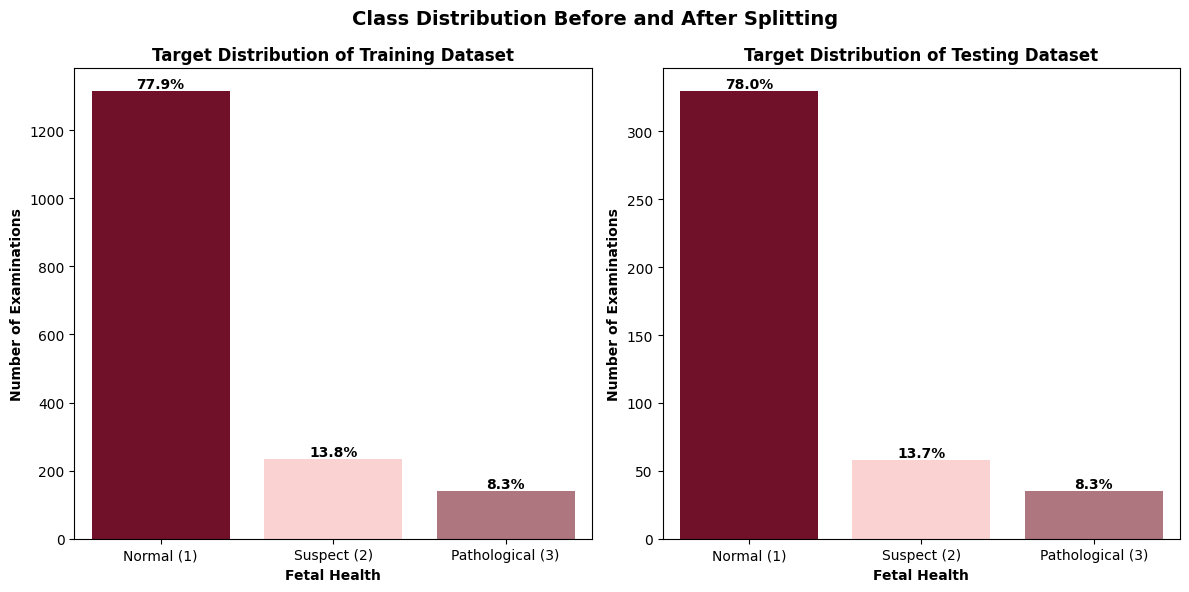

In [19]:
# split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Check the distribution of the train target
target_train = y_train.value_counts().reset_index()
target_train['%percent'] = ((target_train['count'] / len(y_train)) * 100).round(2)
print("--- Train Distribution ---")
print(target_train)

# Check the distribution of the test target
target_test = y_test.value_counts().reset_index()
target_test['%percent'] = ((target_test['count'] / len(y_test)) * 100).round(2)
print("\n--- Test Distribution ---")
print(target_test)

fig, axes =plt.subplots(1,2, figsize = (12,6))
titles = ['Target Distribution of Training Dataset', 'Target Distribution of Testing Dataset']

for ax, data, title in zip( axes, [target_train, target_test], titles):
    sns.barplot(data = data, x = 'fetal_health', y  = 'count', ax = ax, hue = 'fetal_health', palette = mycolor('maroon_1', 'pink_1', 'pink_2'), legend = False)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Fetal Health', fontsize=10, fontweight='bold')
    ax.set_ylabel('Number of Examinations', fontsize=10, fontweight='bold')
    ax.set_xticks(ticks=[0, 1, 2],labels=['Normal (1)', 'Suspect (2)', 'Pathological (3)'])

    # Add percentage labels
    for bar, pct in zip(ax.patches, data['%percent']):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f'{pct:.1f}%',
            ha='center',
            va='bottom',
            fontweight ='bold'
        )

fig.suptitle( 'Class Distribution Before and After Splitting', fontsize=14, fontweight='bold')

plt.savefig("images/target_train_test_distribution", dpi = 300, bbox_inches="tight" )
plt.tight_layout()


**Observation**

The class distributions in the training and testing datasets closely match the distribution observed in the original dataset. This indicates that the train-test split successfully preserved the class proportions, ensuring that both datasets are representative of the overall population.

##### **4.4 Feature Scaling**
The predictor variables are measured on different scales. Feature scaling was therefore performed using standardization on both training and testing data containing predictor variables, which transforms each variable to have a mean of zero and a standard deviation of one. Scaling is particularly important for distance-based and gradient-based machine learning algorithms.

In [20]:
# create a scaler object
# sandardization transforms each feature to have a mean of 0 and a standard deviation of 1
scaler = StandardScaler()

# fit the scaler to the data and apply the transformation
# each value is transformed using:
# z = (x - mean) / standard_deviation
X_train_scaled = scaler.fit_transform(X_train)

# subtracts the mean and divides by the standard deviation for testing data
X_test_scaled = scaler.fit_transform(X_test)

# convert scaled arrays back to DataFrames to retain the original column names
X_train_scaled = pd.DataFrame(data = X_train_scaled, columns = X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(data = X_test_scaled, columns = X_test.columns, index=X_test.index)


##### **4.5 Handling Class Imbalance**
Exploratory analysis revealed that the target variable is imbalanced, with the Normal class representing approximately 78% of observations. To reduce potential model bias towards the majority class, Synthetic Minority Oversampling Technique (SMOTE) was applied to the training data only.

--- Train Distribution of resampled data---
   fetal_health  count  %percent
0           1.0   1316     33.33
1           2.0   1316     33.33
2           3.0   1316     33.33


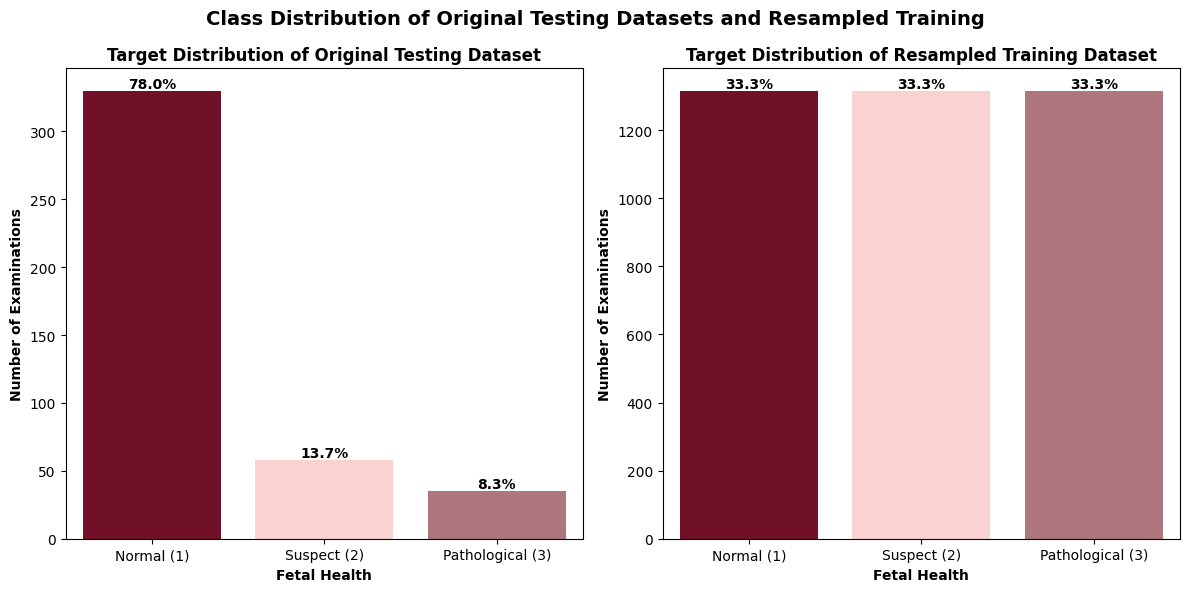

In [21]:
# initialize smote by oversampling minority classes
smote = SMOTE(random_state = 42)

# apply SMOTE to the training data only
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

# Check the distribution of the train target of resampled data
target_train_smote = y_train_smote.value_counts().reset_index()
target_train_smote['%percent'] = ((target_train_smote['count'] / len(y_train_smote)) * 100).round(2)
print("--- Train Distribution of resampled data---")
print(target_train_smote)

# plot the distribution of resampled train data and test data unsampled
fig, axes =plt.subplots(1,2, figsize = (12,6))
titles = ['Target Distribution of Original Testing Dataset', 'Target Distribution of Resampled Training Dataset']

for ax, data, title in zip( axes, [target_test, target_train_smote], titles):
    sns.barplot(data = data, x = 'fetal_health', y  = 'count', ax = ax, hue = 'fetal_health', palette = mycolor('maroon_1', 'pink_1', 'pink_2'), legend = False)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Fetal Health', fontsize=10, fontweight='bold')
    ax.set_ylabel('Number of Examinations', fontsize=10, fontweight='bold')
    ax.set_xticks(ticks=[0, 1, 2],labels=['Normal (1)', 'Suspect (2)', 'Pathological (3)'])

    # Add percentage labels
    for bar, pct in zip(ax.patches, data['%percent']):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f'{pct:.1f}%',
            ha='center',
            va='bottom',
            fontweight ='bold'
        )

fig.suptitle('Class Distribution of Original Testing Datasets and Resampled Training', fontsize=14, fontweight='bold')

plt.tight_layout()

plt.savefig("images/target_train_test_resampled_distribution", dpi = 300, bbox_inches="tight" )


##### **4.6 Data Preparation Summary**
The preprocessing stage involved selecting the predictor variables, separating the features and target variable, partitioning the data into training and testing sets using stratified sampling, standardizing the predictor variables using `StandardScaler`, and addressing class imbalance using SMOTE on the training data only. These steps were used to ensure that the data was appropriately prepared for machine learning model development while minimizing the risk of data leakage and model bias. The resulting datasets were then used for model training and evaluation. The final datasets used for model development and evaluation are:

* `X_train_scaled` and `y_train` – Standardized training data used to develop the baseline models.
* `X_train_smote` and `y_train_smote` – Standardized and resampled training data used to evaluate the impact of SMOTE on model performance.
* `X_test_scaled` and `y_test` – Standardized testing data used for model evaluation.

The baseline models were trained using `X_train_scaled` and `y_train`, while the SMOTE models were trained using `X_train_smote` and `y_train_smote`. All models were evaluated on the same unseen test dataset (`X_test_scaled` and `y_test`) to ensure a fair comparison of performance.

#### **5. Machine Learning Modelling**
The selected models represent a combination of linear, distance-based, bagging, and boosting approaches. This provides a comprehensive comparison of different machine learning techniques for fetal health classification and allows the impact of SMOTE on model performance to be evaluated.

|Model | Motivation|                                                                                                                     
|--|--|  
| **Logistic Regression**        | A simple and interpretable classification algorithm used as a baseline model. Its performance provides a benchmark against more complex machine learning models|
| **K-Nearest Neighbours (KNN)** | A distance-based classifier. Since the predictor variables were standardized during preprocessing, KNN can effectively identify similar fetal examinations based on their feature values. However, it can be sensitive to outliers and irrelevant features. |
| **Random Forest**| An ensemble tree-based model that is robust to outliers, noise, and irrelevant features. It can capture complex non-linear relationships within the data and provides feature importance measures that help identify the most influential predictors of fetal health.|
| **Gradient Boosting** | An ensemble boosting algorithm that builds trees sequentially, with each tree attempting to correct the errors of the previous one. It can capture complex non-linear relationships and often achieves strong predictive performance on structured tabular datasets. |




In [22]:

# define a function to calculate and print performance metrics of the model
def evaluation(y_test, y_pred):

    print("----- Model Performance Metrics -----")

    print(f"Accuracy : {metrics.accuracy_score(y_test, y_pred):.1%}")
    print(f"Precision: {metrics.precision_score(y_test, y_pred, average='macro'):.1%}")
    print(f"Recall   : {metrics.recall_score(y_test, y_pred, average='macro'):.1%}")
    print(f"F1 Score : {metrics.f1_score(y_test, y_pred, average='macro'):.1%}")

    print("\n----- Classification Report -----")
    print(classification_report(y_test, y_pred))

    print("\n----- Confusion Matrix -----")
    print(confusion_matrix(y_test, y_pred))
    
    
# define a function to return accuracy, precision, recall and f1-score metrics   
def performance(y_test, y_pred):

    return {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='macro'),
        'Recall': recall_score(y_test, y_pred, average='macro'),
        'F1 Score': f1_score(y_test, y_pred, average='macro')
    }
    
# create a empty baseline list 
baseline_results = []


##### **5.1 Baseline Models Trained with Original Data**
 

 **5.1.1 Logistic Regression**


In [23]:
from sklearn.linear_model import LogisticRegression

# Logistic Regression model
lr = LogisticRegression(max_iter=1000, random_state=42)

# train and fit the model
lr.fit(X = X_train_scaled, y = y_train)

# generate predictions
lr_y_pred = lr.predict(X_test_scaled)

# evaluate the performance of the model stored as 'results'
results = performance(y_test, lr_y_pred)
print(results)

# add model name to the results
results['Model'] = 'Logistic Regression'


{'Accuracy': 0.8841607565011821, 'Precision': 0.8007298387308799, 'Recall': 0.7677464298153952, 'F1 Score': 0.7831332914400247}


 **5.1.2 K-Nearest Neighbors**


In [24]:
from sklearn.neighbors import KNeighborsClassifier

# K-Nearest Neighbors classifier model
knn = KNeighborsClassifier()

# train and fit the model
knn.fit(X_train_scaled, y_train)

# generate predictions
knn_y_pred = knn.predict(X_test_scaled)

# evaluate the performance of the model stored as 'results'
results = performance(y_test, knn_y_pred)
print(results)

# add model name to the results
results['Model'] = 'K-Nearest Neighbors'


{'Accuracy': 0.900709219858156, 'Precision': 0.8663858953714026, 'Recall': 0.7540130367716574, 'F1 Score': 0.8009641694735938}


**5.1.3 Random Forest**


In [25]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest classifier
rf = RandomForestClassifier(n_estimators= 500, max_depth = None, n_jobs =-1,verbose=1)

# train the model
rf.fit(X_train_scaled, y_train)

# generate predictions
rf_y_pred = rf.predict(X_test_scaled)

# evaluate the performance of the model stored as 'results'
results = performance(y_test, rf_y_pred)
print(results)

# add model name to the results
results['Model'] = 'Random Forest'


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 434 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    1.8s finished


{'Accuracy': 0.9408983451536643, 'Precision': 0.9541073124406458, 'Recall': 0.8497288152460566, 'F1 Score': 0.8921840198152156}


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 434 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 500 out of 500 | elapsed:    0.2s finished


**5.1.4 Gradient Boosting**


In [26]:
from sklearn.ensemble import GradientBoostingClassifier

# Gradient Boosting Classifier model
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=4)

# train and fit the model
gb.fit(X_train_scaled, y_train)

# generate predictions
gb_y_pred = gb.predict(X_test_scaled)

# evaluate performance of the model stored as results
results = performance(y_test, gb_y_pred)
print(results)

# add model name to the results
results['Model'] = 'Gradient Boosting'


{'Accuracy': 0.9456264775413712, 'Precision': 0.961871875338924, 'Recall': 0.8735134597203563, 'F1 Score': 0.9070201276386843}


**5.1.5 Baseline Models Comparison**

------Baseline Model Results------
                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.884161   0.800730  0.767746  0.783133
1  K-Nearest Neighbors  0.900709   0.866386  0.754013  0.800964
2        Random Forest  0.940898   0.954107  0.849729  0.892184
3    Gradient Boosting  0.945626   0.961872  0.873513  0.907020

------Baseline Model Results in Long Format------
                  Model     Metric     Score
0   Logistic Regression   Accuracy  0.884161
1   K-Nearest Neighbors   Accuracy  0.900709
2         Random Forest   Accuracy  0.940898
3     Gradient Boosting   Accuracy  0.945626
4   Logistic Regression  Precision  0.800730
5   K-Nearest Neighbors  Precision  0.866386
6         Random Forest  Precision  0.954107
7     Gradient Boosting  Precision  0.961872
8   Logistic Regression     Recall  0.767746
9   K-Nearest Neighbors     Recall  0.754013
10        Random Forest     Recall  0.849729
11    Gradient Boosting     Recall  0.873513
12  Logis

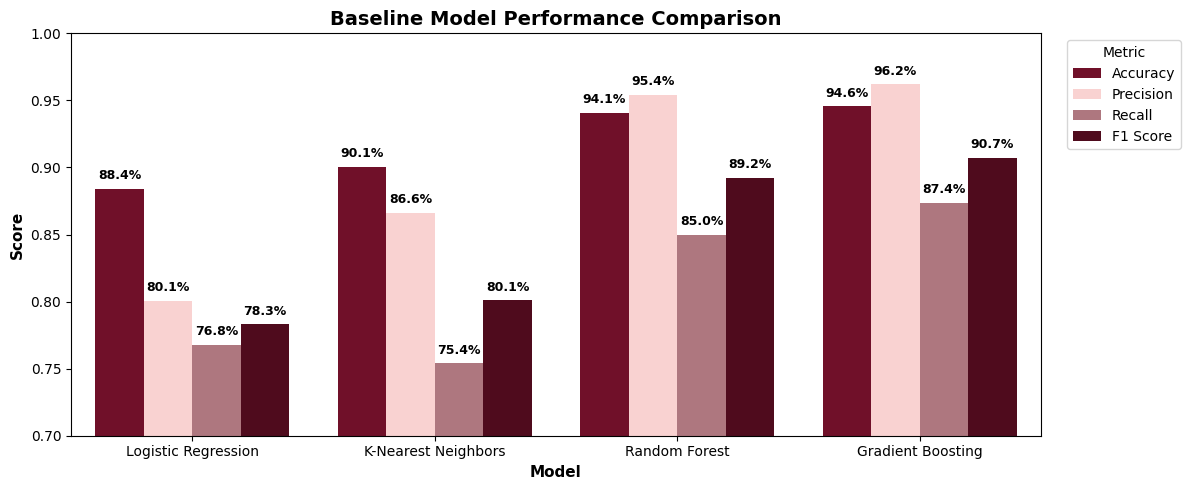

In [27]:
# store the results of the models as a list
baseline_results = [
    {'Model': 'Logistic Regression',
     **performance(y_test, lr_y_pred)},
    
   {'Model': 'K-Nearest Neighbors',
     **performance(y_test, knn_y_pred)},
    
   {'Model': 'Random Forest',
     **performance(y_test, rf_y_pred)},
   
   {'Model': 'Gradient Boosting',
     **performance(y_test, gb_y_pred)}
]

# convert results list to a dataframe
baseline_results_df = pd.DataFrame(baseline_results)

# display the results
print("------Baseline Model Results------")
print(baseline_results_df)

#plot baseline performance
#convert the dataframe form wide to long format
baseline_long = baseline_results_df.melt(id_vars = 'Model',
                                         value_vars=['Accuracy', 'Precision', 'Recall', 'F1 Score'],
                                         var_name='Metric',
                                         value_name='Score')
# display the result
print("\n------Baseline Model Results in Long Format------")
print(baseline_long)

fig, ax = plt.subplots(1,1, figsize = (12,5))

sns.barplot(data = baseline_long, x = 'Model', y = 'Score', ax = ax, hue = 'Metric', 
            palette = mycolor('maroon_1', 'pink_1', 'pink_2',  'maroon') )

ax.set_title('Baseline Model Performance Comparison',fontsize=14, fontweight='bold')
ax.set_xlabel('Model', fontsize=11, fontweight='bold')
ax.set_ylabel('Score',fontsize=11,fontweight='bold')
ax.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_ylim(0.70, 1.00)

for bar in ax.patches:
    height = bar.get_height()

    if height == 0:
        continue

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.005,
        f'{height:.1%}',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

plt.tight_layout()
plt.savefig("images/baseline_models_performance", dpi =300, bbox_inches = 'tight')


**Key Observations:**
* Gradient Boosting achieved the best overall performance, with the highest accuracy (94.6%), precision (96.2%), recall (87.4%), and F1-score (90.7%). Random Forest also performed strongly across all evaluation metrics. Logistic Regression and K-Nearest Neighbors produced lower recall and F1-scores, indicating a reduced ability to correctly identify all fetal health classes. These results suggest that ensemble tree-based methods are better suited to capturing the complex relationships present in the fetal health dataset.


##### **5.2. Models Trained with Data Oversampled with SMOTE**



 **5.2.1 Logistic Regression + SMOTE**


In [28]:
from sklearn.linear_model import LogisticRegression
# Logistic Regression model
lr_smote = LogisticRegression(max_iter=1000, random_state=42)
# train and fit the model
lr_smote.fit(X = X_train_smote, y = y_train_smote)
# generate predictions
lr_smote_y_pred = lr_smote.predict(X_test_scaled)
# evaluate the performance of the model stored as 'results'
results = performance(y_test, lr_smote_y_pred)
print(results)
# add model name to the results
results['Model'] = 'Logistic Regression (SMOTE)'

{'Accuracy': 0.8652482269503546, 'Precision': 0.7473322332233224, 'Recall': 0.825023635368463, 'F1 Score': 0.778921629232777}


 **5.2.2 K-Nearest Neighbours + SMOTE**


In [29]:
from sklearn.neighbors import KNeighborsClassifier
# K-Nearest Neighbors model
knn_smote = KNeighborsClassifier()
# train and fit the model
knn_smote.fit(X = X_train_smote, y = y_train_smote)
# generate predictions
knn_smote_y_pred = knn_smote.predict(X_test_scaled)
# evaluate the performance of the model stored as 'results'
results = performance(y_test, knn_smote_y_pred)
print(results)
# add model name to the results
results['Model'] = 'K- Nearest Neighbors(SMOTE)'

{'Accuracy': 0.8747044917257684, 'Precision': 0.7779821200510856, 'Recall': 0.8480121411155895, 'F1 Score': 0.8030430347088919}


**5.2.3 Random Forest + SMOTE**


In [30]:
from sklearn.ensemble import RandomForestClassifier
# Random Forest model
rf_smote = RandomForestClassifier(n_estimators= 500, max_depth = None, n_jobs =-1,verbose=1)
# train and fit the model
rf_smote.fit(X = X_train_smote, y = y_train_smote)
# generate predictions
rf_smote_y_pred = rf_smote.predict(X_test_scaled)
# evaluate the performance of the model stored as 'results'
results = performance(y_test, rf_smote_y_pred)
print(results)
# add model name to the results
results['Model'] = 'Random Forest (SMOTE)'

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-1)]: Done 434 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    3.3s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.1s


{'Accuracy': 0.933806146572104, 'Precision': 0.8655380663496747, 'Recall': 0.9073195004229486, 'F1 Score': 0.8852215246020075}


[Parallel(n_jobs=8)]: Done 434 tasks      | elapsed:    0.4s
[Parallel(n_jobs=8)]: Done 500 out of 500 | elapsed:    0.4s finished


**5.2.4 Gradient Boosting + SMOTE**


In [31]:
from sklearn.ensemble import GradientBoostingClassifier
# Gradient Boosting model
gb_smote = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=4)
# train and fit the model
gb_smote.fit(X = X_train_smote, y = y_train_smote)
# generate predictions
gb_smote_y_pred = gb_smote.predict(X_test_scaled)
# evaluate the performance of the model stored as 'results'
results = performance(y_test, gb_smote_y_pred)
print(results)
# add model name to the results
results['Model'] = 'Gradient Boosting (SMOTE)'

{'Accuracy': 0.8605200945626478, 'Precision': 0.7610126083530339, 'Recall': 0.9034681793302483, 'F1 Score': 0.8112738024502731}


 **5.2.5 Smote Model Comparison**


------SMOTE Model Results------
                         Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression (SMOTE)  0.865248   0.747332  0.825024  0.778922
1  K-Nearest Neighbors (SMOTE)  0.874704   0.777982  0.848012  0.803043
2        Random Forest (SMOTE)  0.933806   0.865538  0.907320  0.885222
3    Gradient Boosting (SMOTE)  0.860520   0.761013  0.903468  0.811274

------SMOTE Model Results in Long Format------
                          Model     Metric     Score
0   Logistic Regression (SMOTE)   Accuracy  0.865248
1   K-Nearest Neighbors (SMOTE)   Accuracy  0.874704
2         Random Forest (SMOTE)   Accuracy  0.933806
3     Gradient Boosting (SMOTE)   Accuracy  0.860520
4   Logistic Regression (SMOTE)  Precision  0.747332
5   K-Nearest Neighbors (SMOTE)  Precision  0.777982
6         Random Forest (SMOTE)  Precision  0.865538
7     Gradient Boosting (SMOTE)  Precision  0.761013
8   Logistic Regression (SMOTE)     Recall  0.825024
9   K-Nearest Neighbors (SMOTE

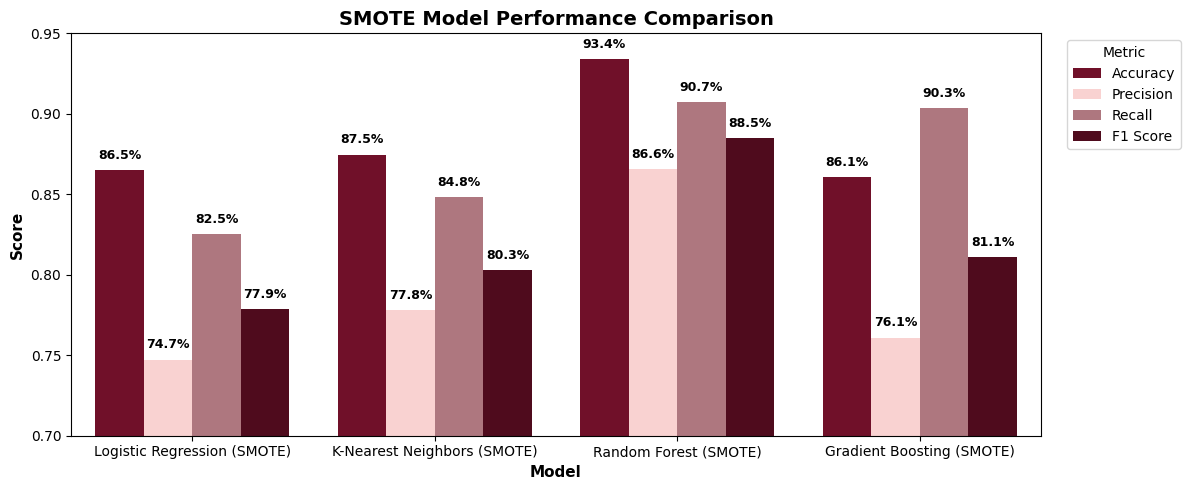

In [32]:
# store the results of the models as a list
smote_results = [
    {'Model': 'Logistic Regression (SMOTE)',
     **performance(y_test, lr_smote_y_pred)},
   
    {'Model': 'K-Nearest Neighbors (SMOTE)',
     **performance(y_test, knn_smote_y_pred)},
    
    {'Model': 'Random Forest (SMOTE)',
     **performance(y_test, rf_smote_y_pred)} ,
    
    {'Model': 'Gradient Boosting (SMOTE)',
     **performance(y_test, gb_smote_y_pred)}
    
]
# convert results list to a dataframe
smote_results_df = pd.DataFrame(smote_results)

# display the results
print("------SMOTE Model Results------")
print(smote_results_df)

#plot baseline performance
#convert the dataframe form wide to long format
smote_long = smote_results_df.melt(id_vars = 'Model',
                                         value_vars=['Accuracy', 'Precision', 'Recall', 'F1 Score'],
                                         var_name='Metric',
                                         value_name='Score')
# display the result
print("\n------SMOTE Model Results in Long Format------")
print(smote_long)



fig, ax = plt.subplots(1,1, figsize = (12,5))

sns.barplot(data = smote_long, x = 'Model', y = 'Score', ax = ax, hue = 'Metric', 
            palette = mycolor('maroon_1', 'pink_1', 'pink_2',  'maroon') )

ax.set_title('SMOTE Model Performance Comparison',fontsize=14, fontweight='bold')
ax.set_xlabel('Model', fontsize=11, fontweight='bold')
ax.set_ylabel('Score',fontsize=11,fontweight='bold')
ax.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_ylim(0.70, 0.95)

for bar in ax.patches:
    height = bar.get_height()

    if height == 0:
        continue

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.005,
        f'{height:.1%}',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

plt.tight_layout()
plt.savefig("images/smote_models_performance", dpi =300, bbox_inches = 'tight')


**Key Observations:**
Applying SMOTE generally increased recall across all models, indicating improved identification of minority fetal health classes. This occurred because the models were exposed to a larger number of synthetic examples from the minority classes (Suspect and Pathological) during training, making them more willing to classify observations into these categories. However, these gains were often accompanied by reductions in precision and overall accuracy, as the increased sensitivity to minority classes also led to more false positive predictions. 

##### **5.3 Feature Importance Analysis**

Since **Gradient Boosting** achieved the highest overall performance among the evaluated models, **permutation importance analysis** was conducted to identify the features that contributed most to the model's predictions.

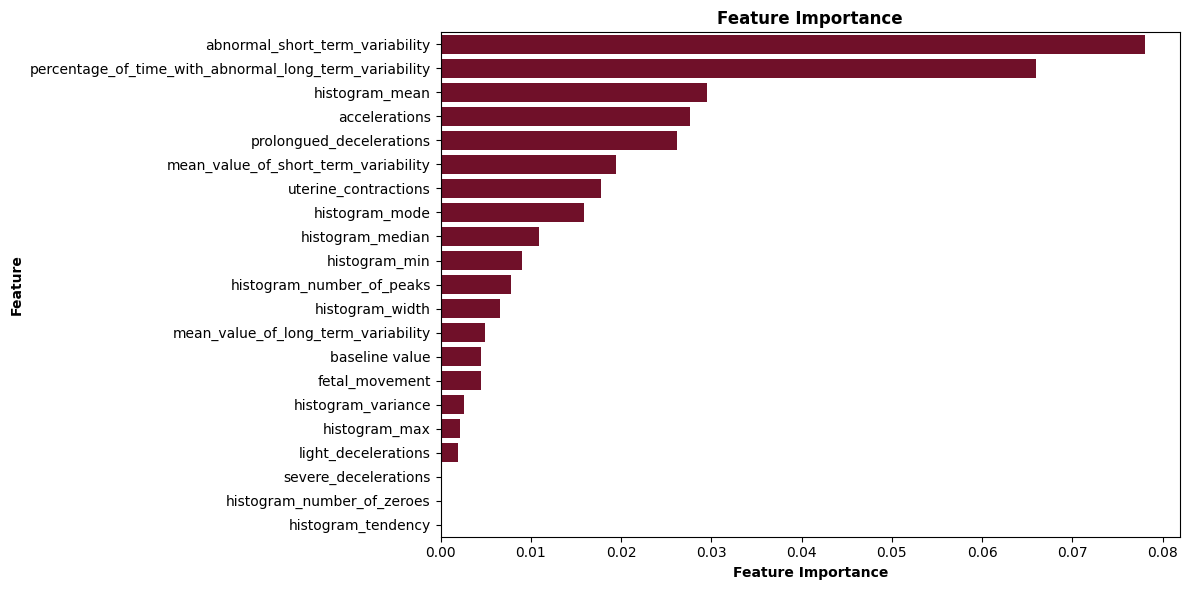

In [45]:
# extract feature importance
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(estimator=gb, X=X_test_scaled, y=y_test, n_repeats=10, random_state=42)
perm_df = pd.DataFrame({'Feature': X.columns, 'Importance': perm_importance.importances_mean})
perm_df = perm_df.sort_values(by='Importance', ascending=False)

# plot feature importance bar graph
fig, ax = plt.subplots(1,1, figsize = (12,6))
sns.barplot(data = perm_df, x = 'Importance', y = 'Feature', color = "#800021" , ax = ax)
ax.set_title('Feature Importance', fontsize = 12, fontweight = 'bold')
ax.set_xlabel('Feature Importance', fontsize = 10, fontweight = 'bold')
ax.set_ylabel('Feature', fontsize = 10, fontweight = 'bold')
 
plt.tight_layout()
plt.savefig("images/feature_importance", dpi = 300, bbox_inches = 'tight')

**Key Observations:**
- Features related to **fetal heart rate variability** were the most influential predictors of fetal health. In particular, `abnormal_short_term_variability`, `mean_value_of_short_term_variability`, and `percentage_of_time_with_abnormal_long_term_variability` received the highest importance scores.
- Several **histogram-based features**, particularly `histogram_mean`, `histogram_mode`, and `histogram_median`, were also identified as important predictors. This suggests that the overall fetal heart rate signals contain valuable information for distinguishing between fetal health classes.
-  `prolonged_decelerations` was one of the most influential features, supporting earlier findings from the exploratory analysis that prolonged decelerations are strongly associated with adverse fetal outcomes.
- `accelerations` and `uterine_contractions` contributed moderately to the model's predictions, indicating that they provide useful information but are less influential than variability and histogram features.
- Features such as `severe_decelerations`, `histogram_number_of_zeroes`, `histogram_tendency`, and `light_decelerations` had relatively low importance scores, suggesting they contributed less to the model's decision-making process.

####  **6. Key Findings**

 - **Class imbalance**: The dataset is imbalanced, with most examinations classified as **Normal (77.9%)**, while **Suspect (13.8%)** and **Pathological (8.3%)** cases are much less common.
- **Baseline models**: Four machine learning models were evaluated on the original dataset. **Gradient Boosting achieved the best overall performance**, with an accuracy of **94.6**%, precision of **96.2%**, recall of **87.4%**, and an F1-score of **90.7%**. **Random Forest** also performed well, while Logistic Regression and K-Nearest Neighbours produced lower recall and F1-scores.
- **Effect of SMOTE**: Applying SMOTE increased the number of minority-class examples during training, making the models more willing to predict **Suspect** and **Pathological** cases. As a result, recall generally improved because more high-risk cases were correctly identified. However, this also increased false positive predictions, leading to lower precision and, in some cases, lower overall accuracy.
- **Important features**: Features related to fetal heart rate variability and decelerations, particularly abnormal short-term variability and prolonged decelerations, showed the strongest relationships with fetal health status and appear to be important predictors.
- The feature importance analysis indicates that measures of **fetal heart rate variability**, **histogram characteristics**, and **prolonged decelerations** are the most influential predictors of fetal health.

#### **7. Recommendations**
- **Gradient Boosting is recommended as the preferred model** for this dataset, as it achieved the highest overall performance and maintained a good balance between precision and recall.
- Future model development should focus on improving the identification of **Pathological** fetal health cases, as these represent the highest clinical risk and the smallest proportion of the dataset.
- Hyperparameter tuning using techniques such as **Grid Search** or **Random Search** should be performed to determine whether further performance improvements can be achieved.

